In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [32]:
df = pd.read_csv('../data/transaction.csv',sep='\t')

In [5]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Amount,Merchant_Category,Merchant_ID,Card_Type,Transaction_Type,Country,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Device_Type,Fraud_Flag
0,1,25795,28-05-2025 11:54,81.53,Online Services,8459,Gold,POS,Germany,1,1,0,1.61,11,Web,0
1,2,10860,11-09-2024 20:26,52.19,Fuel,8205,Debit,ATM,Germany,0,1,0,15.77,20,Web,0
2,3,86820,02-11-2024 12:39,27.70,Utilities,8076,Gold,Online,USA,0,1,0,9.19,12,Terminal,0
3,4,64886,08-10-2024 21:58,9.80,Clothing,3244,Gold,ATM,USA,0,1,0,9.42,21,Web,0
4,5,16265,25-05-2024 20:01,178.06,Electronics,3675,Gold,ATM,Germany,0,1,1,1.32,20,Web,0


In [6]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      500000 non-null  int64  
 1   Customer_ID         500000 non-null  int64  
 2   Transaction_Date    500000 non-null  object 
 3   Amount              500000 non-null  float64
 4   Merchant_Category   500000 non-null  object 
 5   Merchant_ID         500000 non-null  int64  
 6   Card_Type           500000 non-null  object 
 7   Transaction_Type    500000 non-null  object 
 8   Country             500000 non-null  object 
 9   Is_International    500000 non-null  int64  
 10  Is_Chip             500000 non-null  int64  
 11  Is_Pin_Used         500000 non-null  int64  
 12  Distance_From_Home  500000 non-null  float64
 13  Hour_of_Day         500000 non-null  int64  
 14  Device_Type         500000 non-null  object 
 15  Fraud_Flag          500000 non-nul

Transaction_ID        0
Customer_ID           0
Transaction_Date      0
Amount                0
Merchant_Category     0
Merchant_ID           0
Card_Type             0
Transaction_Type      0
Country               0
Is_International      0
Is_Chip               0
Is_Pin_Used           0
Distance_From_Home    0
Hour_of_Day           0
Device_Type           0
Fraud_Flag            0
dtype: int64

In [7]:
df = df.drop_duplicates()
len(df)

500000

In [34]:
fraud_percent = (df['Fraud_Flag'].sum() / len(df)) * 100
print(f"Fraud Percentage: {fraud_percent:.2f}%")
df['Fraud_Flag'].value_counts()

Fraud Percentage: 1.50%


Fraud_Flag
0    492500
1      7500
Name: count, dtype: int64

In [9]:
df.describe()

,Transaction_ID,Customer_ID,Amount,Merchant_ID,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Fraud_Flag
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.00000,500000.000000,500000.000000,500000.000000
mean,250000.500000,55007.627196,145.268014,5501.226076,0.149132,0.300222,0.19980,5.001699,11.513692,0.015000
std,144337.711635,25995.094710,120.882326,2597.483856,0.356219,0.458355,0.39985,4.998739,6.915274,0.121553
min,1.000000,10000.000000,1.190000,1000.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,125000.750000,32490.000000,60.790000,3254.000000,0.000000,0.000000,0.00000,1.430000,6.000000,0.000000
50%,250000.500000,55056.500000,109.160000,5500.000000,0.000000,0.000000,0.00000,3.480000,12.000000,0.000000
75%,375000.250000,77510.000000,192.232500,7751.000000,0.000000,1.000000,0.00000,6.920000,18.000000,0.000000
max,500000.000000,99998.000000,1731.550000,9998.000000,1.000000,1.000000,1.00000,68.130000,23.000000,1.000000


In [10]:
df.mean(numeric_only=True)

Transaction_ID        250000.500000
Customer_ID            55007.627196
Amount                   145.268014
Merchant_ID             5501.226076
Is_International           0.149132
Is_Chip                    0.300222
Is_Pin_Used                0.199800
Distance_From_Home         5.001699
Hour_of_Day               11.513692
Fraud_Flag                 0.015000
dtype: float64

In [11]:
df.median(numeric_only=True)

Transaction_ID        250000.50
Customer_ID            55056.50
Amount                   109.16
Merchant_ID             5500.00
Is_International           0.00
Is_Chip                    0.00
Is_Pin_Used                0.00
Distance_From_Home         3.48
Hour_of_Day               12.00
Fraud_Flag                 0.00
dtype: float64

In [12]:
df.std(numeric_only=True)

Transaction_ID        144337.711635
Customer_ID            25995.094710
Amount                   120.882326
Merchant_ID             2597.483856
Is_International           0.356219
Is_Chip                    0.458355
Is_Pin_Used                0.399850
Distance_From_Home         4.998739
Hour_of_Day                6.915274
Fraud_Flag                 0.121553
dtype: float64

In [14]:
df.quantile([0.25, 0.50, 0.75], numeric_only=True)

,Transaction_ID,Customer_ID,Amount,Merchant_ID,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Fraud_Flag
0.25,125000.75,32490.0,60.7900,3254.0,0.0,0.0,0.0,1.43,6.0,0.0
0.50,250000.50,55056.5,109.1600,5500.0,0.0,0.0,0.0,3.48,12.0,0.0
0.75,375000.25,77510.0,192.2325,7751.0,0.0,1.0,0.0,6.92,18.0,0.0


In [15]:
df.quantile([0.90, 0.95, 0.99], numeric_only=True)

,Transaction_ID,Customer_ID,Amount,Merchant_ID,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Fraud_Flag
0.90,450000.10,91043.00,302.381,9100.0,1.0,1.0,1.0,11.52,21.0,0.0
0.95,475000.05,95533.00,385.460,9551.0,1.0,1.0,1.0,14.97,22.0,0.0
0.99,495000.01,99095.01,579.530,9908.0,1.0,1.0,1.0,23.01,23.0,1.0


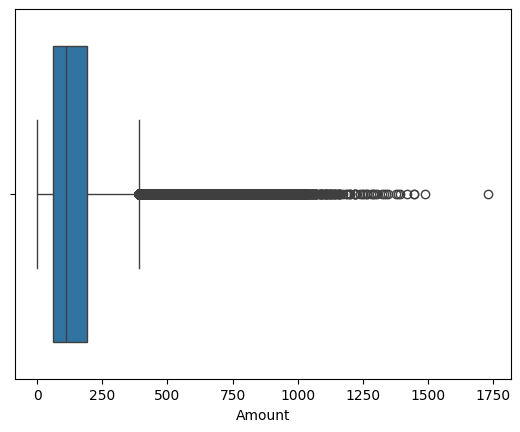

In [16]:
sns.boxplot(x=df['Amount'])
plt.show()

In [18]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[(df['Amount'] < lower) |
              (df['Amount'] > upper)]
len(outliers)

24215

In [19]:
df['zscore'] = np.abs(stats.zscore(df['Amount']))
df[df['zscore'] > 3]

,Transaction_ID,Customer_ID,Transaction_Date,Amount,Merchant_Category,Merchant_ID,Card_Type,Transaction_Type,Country,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Device_Type,Fraud_Flag,zscore
222,223,59811,18-06-2024 23:53,515.75,Groceries,5122,Debit,ATM,Germany,0,0,0,8.36,23,Web,0,3.064818
250,251,87371,13-03-2025 07:42,661.91,Online Services,7127,Platinum,POS,Singapore,1,0,1,4.69,7,Terminal,0,4.273929
273,274,58354,01-02-2024 18:53,595.86,Health,4423,Platinum,POS,Singapore,0,0,0,3.31,18,Web,0,3.727530
339,340,95314,27-12-2024 06:40,577.67,Electronics,7844,Debit,ATM,Canada,1,1,0,0.80,6,Terminal,0,3.577052
374,375,80031,15-04-2025 05:01,529.89,Electronics,2600,Platinum,Online,USA,0,0,0,7.46,5,Mobile,0,3.181792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499699,499700,37431,09-04-2024 09:47,725.67,Utilities,1892,Platinum,ATM,France,0,1,0,2.62,9,Terminal,0,4.801385
499740,499741,88212,20-08-2024 17:07,631.78,Food,6081,Platinum,ATM,India,0,0,0,2.93,17,Web,0,4.024678
499821,499822,62141,12-07-2025 06:45,770.53,Groceries,4965,Credit,Online,India,0,0,0,1.27,6,Mobile,0,5.172490
499925,499926,62715,17-08-2024 11:24,907.48,Utilities,3372,Platinum,ATM,Singapore,0,0,0,13.93,11,Mobile,0,6.305411


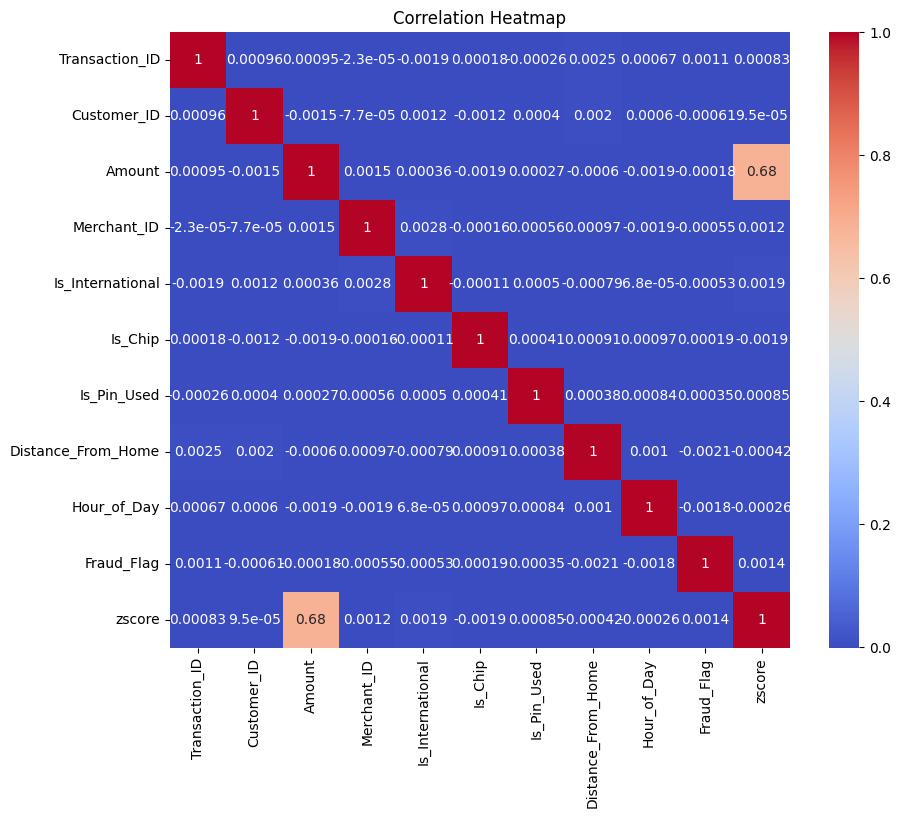

In [20]:
df['Transaction_Date'] = pd.to_datetime(
    df['Transaction_Date'],
    dayfirst=True
)
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

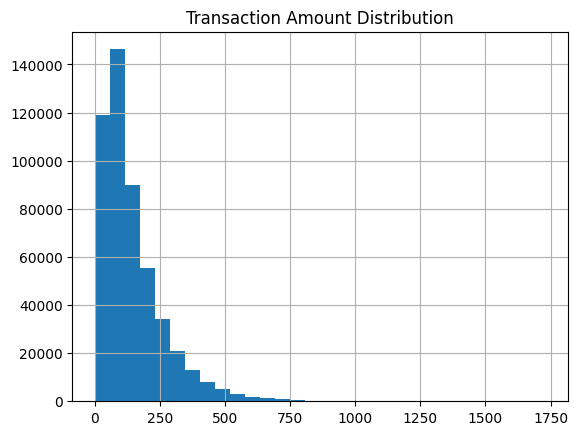

In [21]:
df['Amount'].hist(bins=30)

plt.title('Transaction Amount Distribution')
plt.show()

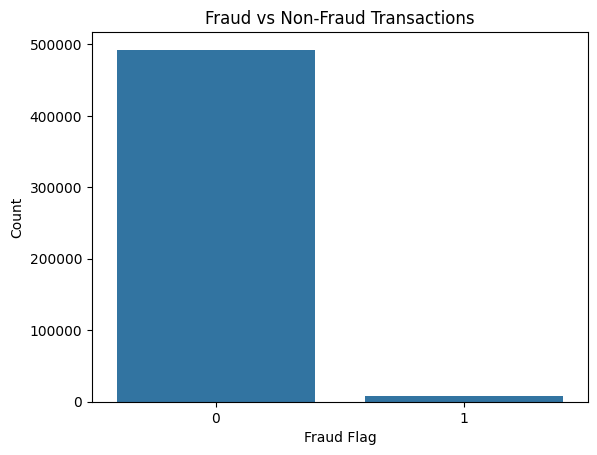

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Fraud_Flag', data=df)

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud Flag')
plt.ylabel('Count')
plt.show()

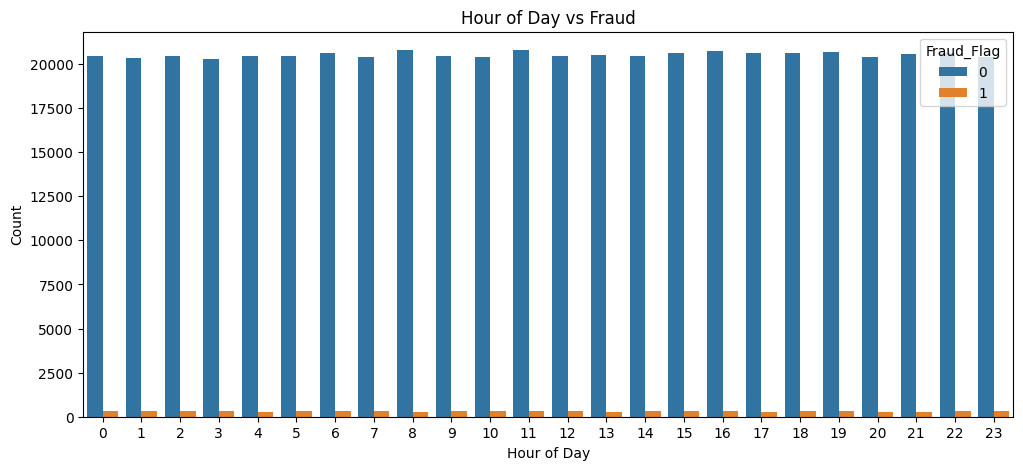

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.countplot(x='Hour_of_Day', hue='Fraud_Flag', data=df)

plt.title('Hour of Day vs Fraud')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.show()

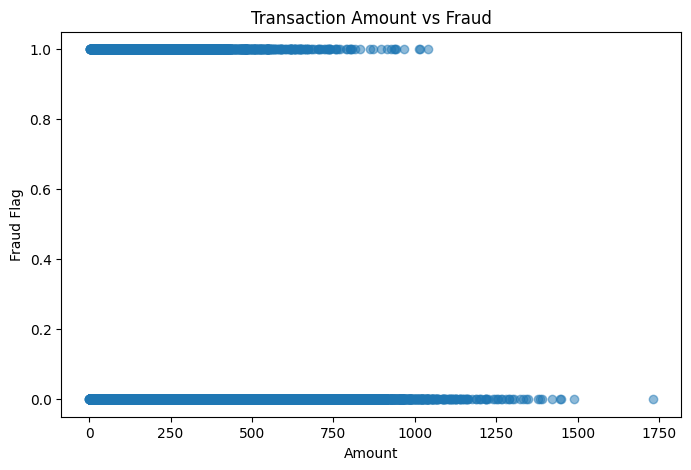

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['Amount'], df['Fraud_Flag'], alpha=0.5)

plt.title('Transaction Amount vs Fraud')
plt.xlabel('Amount')
plt.ylabel('Fraud Flag')
plt.show()

In [25]:
from scipy.stats import ttest_ind

fraud = df[df['Fraud_Flag'] == 1]['Amount']
non_fraud = df[df['Fraud_Flag'] == 0]['Amount']

t_stat, p_value = ttest_ind(fraud, non_fraud)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("Transaction amount significantly affects fraud occurrence.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("Transaction amount does not significantly affect fraud occurrence.")

T-Statistic: -0.12429769515446226
P-Value: 0.901079622117372
Fail to Reject the Null Hypothesis
Transaction amount does not significantly affect fraud occurrence.


In [26]:
high_value = df[df['Amount'] > df['Amount'].quantile(0.95)]

print("High Value Transactions:", len(high_value))

High Value Transactions: 24998


In [27]:
late_night = df[(df['Hour_of_Day'] >= 0) &
                (df['Hour_of_Day'] <= 5)]

print("Late Night Transactions:", len(late_night))

Late Night Transactions: 124351


In [30]:
far_home = df[
    df['Distance_From_Home'] >
    df['Distance_From_Home'].quantile(0.95)
]

print("Far From Home Transactions:", len(far_home))

Far From Home Transactions: 24994


In [29]:
web_txns = df[df['Device_Type'] == 'Web']

print("Web Transactions:", len(web_txns))

Web Transactions: 166038
